In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [68]:
# Load the  dataset
df = pd.read_csv('data\WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [69]:
# Checking the columns
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [70]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [71]:
df.shape

(7043, 21)

In [72]:
# Finding missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [73]:
# Data type information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [74]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

C:\Users\anupa\AppData\Local\Temp\ipykernel_12048\1422790543.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=['steelblue','salmon'])


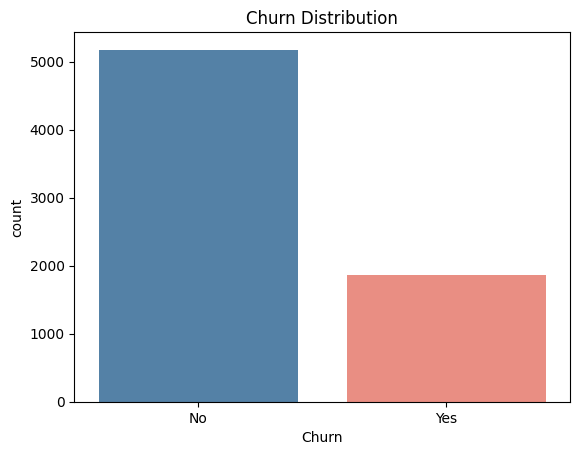

In [75]:
sns.countplot(x='Churn', data=df, palette=['steelblue','salmon'])
plt.title('Churn Distribution')
plt.show()

In [76]:
# Convert TotalCharges from text to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors ='coerce')

# Verify
df['TotalCharges'].dtype

dtype('float64')

In [77]:
# Convert churn from yes/no to 1/0

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Churn dtype: {df['Churn'].dtype}")
print(f"Overall Churn Rate: {df['Churn'].mean()*100:.2f}%")

Churn dtype: int64
Overall Churn Rate: 26.54%


In [78]:
# Churn rate by Contract type
contract_churn = df.groupby('Contract')['Churn'].mean()* 100
print(contract_churn)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


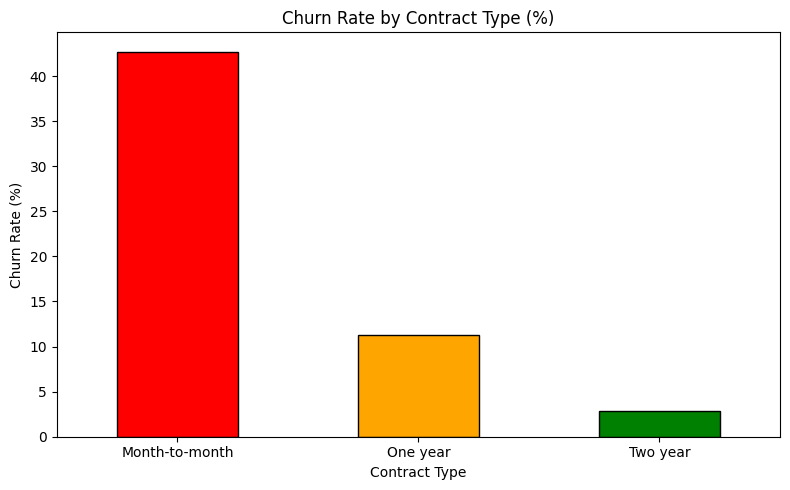

In [79]:
plt.figure(figsize=(8, 5))

contract_churn.plot(kind='bar', 
                    color=['red','orange','green'],
                    edgecolor='black')

plt.title('Churn Rate by Contract Type (%)')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('contract_churn.png', dpi=150)
plt.show()

In [80]:
# Average tenure of churned vs not churned
tenure_churn = df.groupby('Churn')['tenure'].mean()
print(tenure_churn)

Churn
0    37.569965
1    17.979133
Name: tenure, dtype: float64


C:\Users\anupa\AppData\Local\Temp\ipykernel_12048\402853754.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df,


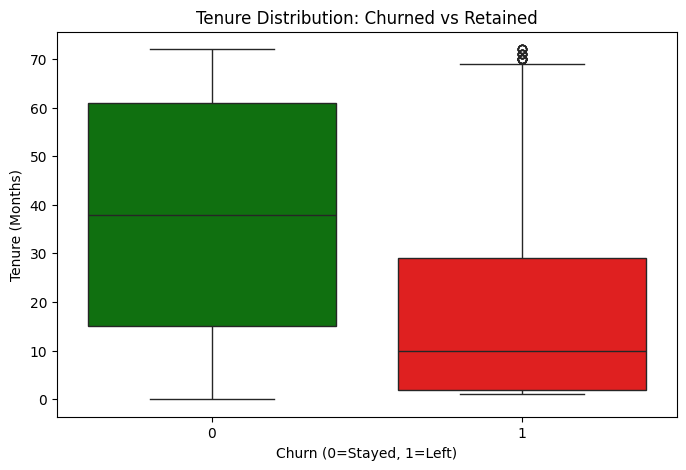

In [81]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='tenure', data=df,
            palette=['green','red'])
plt.title('Tenure Distribution: Churned vs Retained')
plt.xlabel('Churn (0=Stayed, 1=Left)')
plt.ylabel('Tenure (Months)')
plt.savefig('tenure_churn.png', dpi=150)
plt.show()

In [82]:
charges_churn = df.groupby('Churn')['MonthlyCharges'].mean()
print(charges_churn)

Churn
0    61.265124
1    74.441332
Name: MonthlyCharges, dtype: float64


C:\Users\anupa\AppData\Local\Temp\ipykernel_12048\3336040255.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Churn', y='MonthlyCharges',


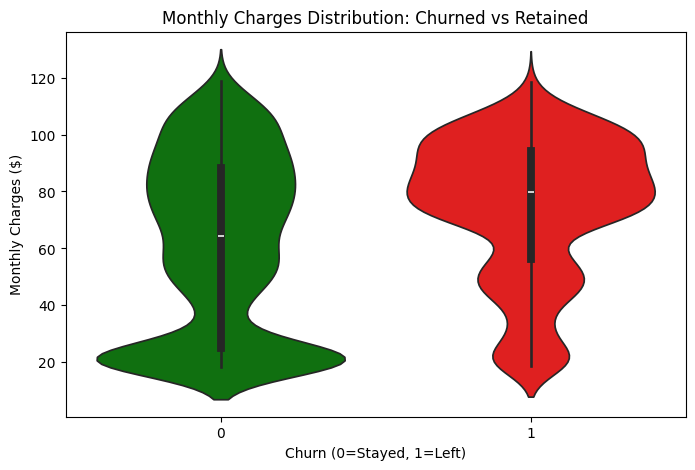

In [83]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='Churn', y='MonthlyCharges', 
               data=df, palette=['green','red'])
plt.title('Monthly Charges Distribution: Churned vs Retained')
plt.xlabel('Churn (0=Stayed, 1=Left)')
plt.ylabel('Monthly Charges ($)')
plt.savefig('charges_churn.png', dpi=150)
plt.show()

In [85]:
internet_churn = df.groupby('InternetService')['Churn'].mean() * 100
print(internet_churn)

InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn, dtype: float64
